<a href="https://colab.research.google.com/github/NethsanduKumarasinghe/EN3160_Assignment_01/blob/main/EN3160_Assignment_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EN3160 Assignment 1
## Intensity Transformations and Neighborhood Filtering

**Name:** Kumarasinghe M. N.  
**Index:** 230355X

In [4]:
from google.colab import files

uploaded = files.upload()

Saving images.zip to images.zip


In [5]:
import zipfile

with zipfile.ZipFile("images.zip", "r") as zip_ref:
    zip_ref.extractall("/content")

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## Question 1

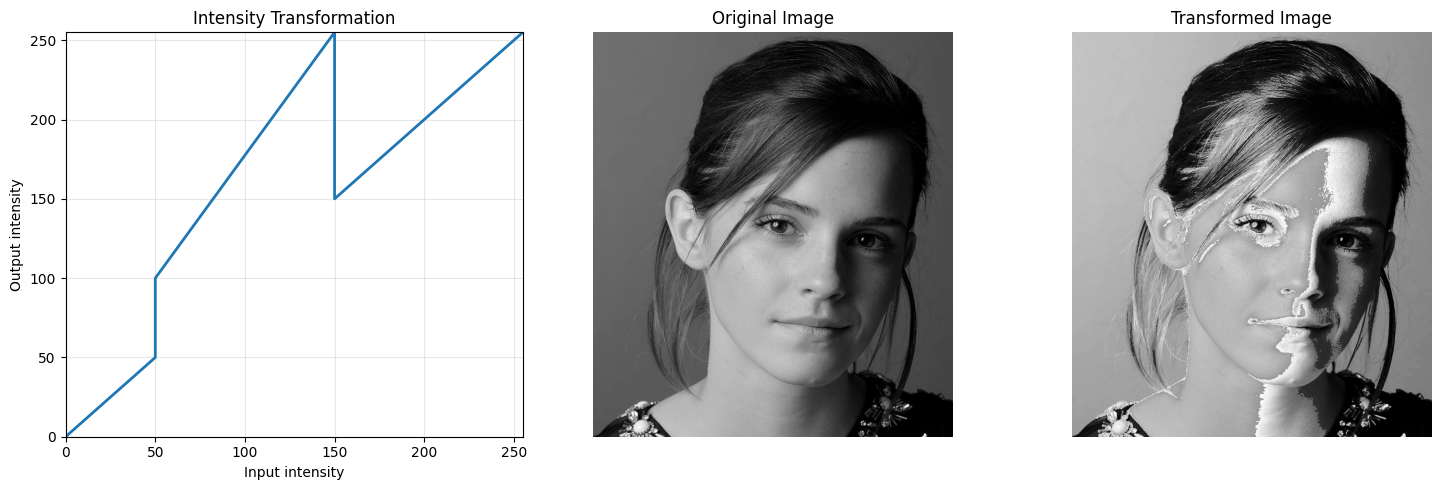

In [32]:
image_path = "/content/images/q1.jpeg"

im = cv.imread(image_path, cv.IMREAD_GRAYSCALE)


def intensity_transform(im, breakpoints):
    output = np.zeros_like(im, dtype=np.float32)

    for i in range(len(breakpoints) - 1):
        x1, y1 = breakpoints[i]
        x2, y2 = breakpoints[i + 1]

        if x1 == x2:
            continue

        mask = (im >= x1) & (im < x2)

        output[mask] = y1 + (im[mask] - x1) * (y2 - y1) / (x2 - x1)

    output[im >= breakpoints[-1, 0]] = breakpoints[-1, 1]

    return np.clip(output, 0, 255).astype(np.uint8)


breakpoints = np.array([
    [0, 0],
    [50, 50],
    [50,100],
    [150, 255],
    [150,150],
    [255, 255]
])

transformed = intensity_transform(im, breakpoints)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
x_plot = breakpoints[:, 0]
y_plot = breakpoints[:, 1]
plt.plot(x_plot, y_plot, linewidth=2)
plt.xlim(0, 255)
plt.ylim(0, 255)

plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Intensity Transformation")

plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.imshow(im, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(transformed, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()

plt.show()

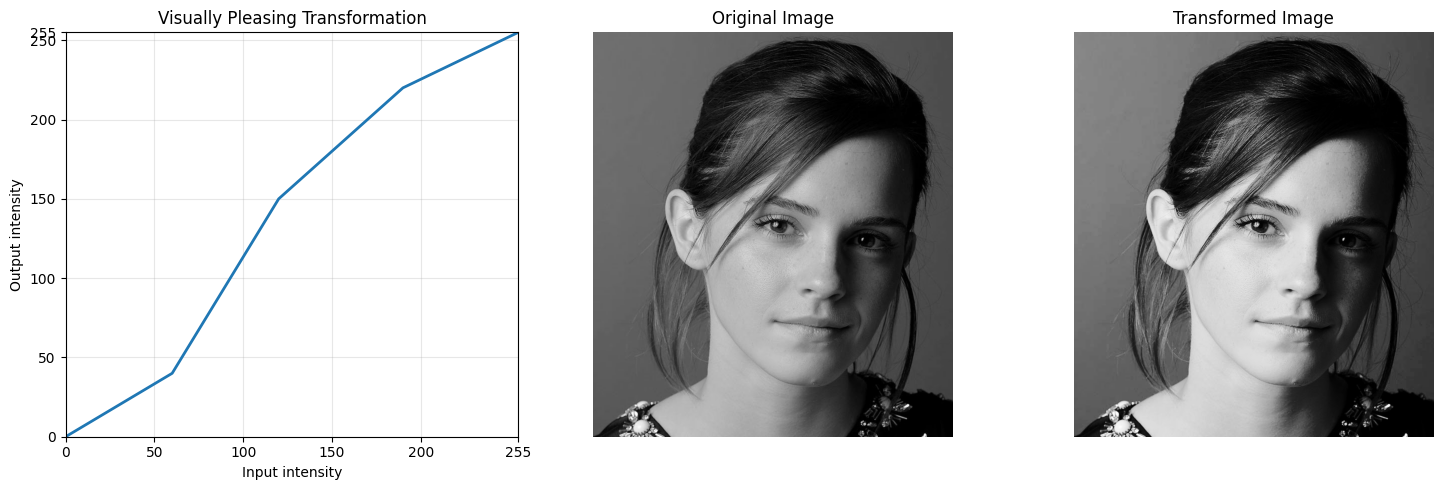

In [33]:
breakpoints_pleasing = np.array([
    [0, 0],
    [60, 40],
    [120, 150],
    [190, 220],
    [255, 255]
])

transformed_pleasing = intensity_transform(im, breakpoints_pleasing)

x_plot = breakpoints_pleasing[:, 0]
y_plot = breakpoints_pleasing[:, 1]

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(x_plot, y_plot, linewidth=2)
plt.xlim(0, 255)
plt.ylim(0, 255)
plt.xticks([0, 50, 100, 150, 200, 255])
plt.yticks([0, 50, 100, 150, 200, 250, 255])
plt.xlabel("Input intensity")
plt.ylabel("Output intensity")
plt.title("Visually Pleasing Transformation")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.imshow(im, cmap="gray", vmin=0, vmax=255)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(transformed_pleasing, cmap="gray", vmin=0, vmax=255)
plt.title("Transformed Image")
plt.axis("off")

plt.tight_layout()
plt.show()